# Perturbation Analysis Workflow: In Vivo Brain CRISPR Atlas Example

**Authors and Contributors:** <br>
*NVIDIA:* Sara Rabhi, Maria Korshunova, Sajad Darabi, Severin Dicks, Taurean Dyer, Gary Burnett, T.J. Chen, Laksshman Sundaram <br>
*PerturbAI:* David DeTomaso, Grace X.Y. Zheng <br>
*Sanders Lab:* Salma Ali, Stephan J. Sanders <br>
*Jin lab:* Tuo Shi, Seoyeon Kim, Xin Jin <br>

**Maintainers:** Gary Burnett, Severin Dicks, Taurean Dyer, T.J. Chen


Please ensure you are using the Advanced Instance for this notebook, and plan for approximately 10-20 minutes for the data to download and extract from the archive.

Perturbation experiments directly link biological interventions (like CRISPR) to molecular and cellular changes, enabling causal inference that observational data lack. In vivo single cell perturbation atlases offer rich, context-diverse data to help understand gene functions and cellular responses. The ~3.5M cell data set included in this notebook is an _in vivo_, juvenile mouse whole-brain single-nucleus CRISPR atlas with snRNA-seq profiles, and CRISPR guides targeting 2000 disease-associated genes. In this notebook, you will:

* Enable biological discovery without downsampling by loading and analyzing million-cell–scale, in vivo perturbation data on GPU with Dask/RAPIDS.
* Capture biological state changes for robust perturbation analysis by building GPU-accelerated, normalized PCA embeddings.
* Visualize and explore the data using UMAP
* Quantify how perturbations reshape cell-state distributions by computing E-distance effect sizes across gene and cell type pairs.
* Identify and prioritize genes and cell types for follow-up by constructing and ranking a global perturbation-response map using E-distance matrices (compute * 1-sided E-distance per target gene and cell type (group_name) in PCA space)
* Pinpoint vulnerable cell types and link perturbation effects to disease or pathway hypotheses by overlaying external gene lists and visualizing results with boxplots .


In [ ]:
import gc
import os
import dask
import numpy as np
import pandas as pd
import anndata as ad
import zarr
import cupy as cp
import rapids_singlecell as rsc
from rapids_singlecell.ptg import Distance as EDistance
import matplotlib.pyplot as plt
import seaborn as sns

from anndata.experimental import read_elem_lazy as read_dask

DATA_PATH_ZARR = "/data/nvcell/datasets/perturbai/WB8588_screen_gex_filtered_reassigned_final.zarr" # Change this to your own dataset path
OUT_DIR = "/data/nvcell/datasets/perturbai/training_data/rapids_edist_results" # Change this to your own results directory
GROUPBY = "target_gene"
CONTROL = "Non_target"
CELLTYPE = "group_name"
TARGET_CELLTYPE = "target_celltype"
SPARSE_CHUNK_SIZE = 2048
N_PCS = 50
N_TOP_HVG = 2000

os.makedirs(OUT_DIR, exist_ok=True)

## Load and Prepare Data

Let's start by creating our _in vivo_ mouse brain atlas dataset and loading it into an AnnData object, which is in zarr format on HuggingFace. The original 7.7 million pre-processed data was filtered  to a processed subset of ~3.5M cells, with expression of 17,070 genes, expression of 8,588 guides, and meta data for each cell. This should take between 5-30 minutes to download.

* If the archive is missing, the notebook downloads it and unpacks it into a Zarr directory on disk (delete to re-download)
* We then open the Zarr store and read in the expression matrix, cell metadata, and gene metadata into AnnData


In [2]:
data_dir = os.getcwd()+"/h5"
url = "https://huggingface.co/datasets/perturbai/wholebrain_crispr_atlas/resolve/main/analysis/preprocessed_gex.zarr.tar.gz?download=true"
output = data_dir+'/preprocessed_gex.zarr.tar.gz'
final = data_dir+'/pert/preprocessed_gex.zarr'
OUT_DIR = os.getcwd()+"/singlet_gex.zarr" # Change this to your own results directory-dir='
GROUPBY = "target_gene"
CONTROL = "Non_target"
CELLTYPE = "group_name"
TARGET_CELLTYPE = "target_celltype"
SPARSE_CHUNK_SIZE = 2048
N_PCS = 50
N_TOP_HVG = 2000

if not os.path.exists(final):
    if not os.path.exists(data_dir):
        print('creating data directory')
        os.system(f'mkdir {data_dir}')
    else:
        print(f'{data_dir} directory found')

    if not os.path.isfile(output):
        print(f'Downloading cell data into {output}, this make take 5-30 minutes...')
        os.system(f"wget -q -O {output} {url}") # replace with f"wget -nv --show-progress -O {output} {url}" for more verbose output
        print(f'Completed download')
    else:
        print(f'{output} dataset found (check as needed)')

creating data directory
Completed download


In [3]:
#Extract the archive into a zarr file
print('Extracting archive (this may take 5-10 minutes)...')
os.system(f"tar -xzf {output} --warning=none") #os.system(f"tar -xvzf {output}") for verbose
print('Extraction completed')

Extracting archive (this may take 5-10 minutes)...
Extraction completed


In [4]:
OUT_DIR = os.getcwd()+"/singlet_gex.zarr" # Change this to your own results directory-dir='

## Set up the Dask Cluster

This section configures a local Dask cluster so large computations can be distributed across GPU resources, first checking if Dask-CUDA is available.

* The cluster is configured with options such as which GPUs to use, how many threads per worker, and which communication protocol to use. We choose 1 GPU for this tutorial
* If GPU-based clustering is not available, the notebook falls back to a more limited mode, and you can still run a subset of the analyses.

In [5]:
# Initialize Dask cluster first
try:
    from dask_cuda import LocalCUDACluster
    from dask.distributed import Client
except ImportError:
    LocalCUDACluster = None
    Client = None

# --- Cluster parameters (adjust for your machine) ---
CUDA_VISIBLE_DEVICES = "0" #keep 1 GPU for this tutorial
THREADS_PER_WORKER = 1
PROTOCOL = "ucx"
RMM_POOL_SIZE = "12GB"
RMM_MAXIMUM_POOL_SIZE = "35GB"

if LocalCUDACluster is not None and Client is not None:
    try:
        _has_client = client is not None
    except NameError:
        _has_client = False
    if not _has_client:
        cluster = LocalCUDACluster(
            CUDA_VISIBLE_DEVICES=CUDA_VISIBLE_DEVICES,
            threads_per_worker=THREADS_PER_WORKER,
            protocol=PROTOCOL,
            rmm_pool_size=RMM_POOL_SIZE,
            rmm_maximum_pool_size=RMM_MAXIMUM_POOL_SIZE,
            rmm_allocator_external_lib_list="cupy",
        )
        client = Client(cluster)
        print(f"Dask cluster initialized (GPUs={CUDA_VISIBLE_DEVICES}).")
        client
    else:
        print("Dask client already exists; using existing cluster.")
else:
    print("dask-cuda not installed; run with Zarr + Dask for out-of-core.")

2026-03-08 07:33:58 | [INFO] State start
2026-03-08 07:33:58 | [INFO] init
2026-03-08 07:33:59 | [INFO]   Scheduler at:     ucx://127.0.0.1:58789
2026-03-08 07:33:59 | [INFO]   dashboard at:  http://127.0.0.1:8787/status
2026-03-08 07:33:59 | [INFO] Registering Worker plugin shuffle
2026-03-08 07:33:59 | [INFO]         Start Nanny at: 'ucx://127.0.0.1:46077'
2026-03-08 07:34:00 | [INFO] Register worker addr: ucx://127.0.0.1:43847 name: 0
2026-03-08 07:34:00 | [INFO] Starting worker compute stream, ucx://127.0.0.1:43847
2026-03-08 07:34:00 | [INFO] Starting established connection to ucx://127.0.0.1:58789
2026-03-08 07:34:00 | [INFO] Receive client connection: Client-2cc8fab7-1ac1-11f1-8176-16b21db8a34b
2026-03-08 07:34:00 | [INFO] Starting established connection to ucx://127.0.0.1:58789


Dask cluster initialized (GPUs=0).


2026-03-08 07:39:48 | [INFO] Event loop was unresponsive in Nanny for 4.34s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-03-08 07:39:48 | [INFO] Event loop was unresponsive in Scheduler for 4.34s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


## Optional: Configure RAPIDS memory and scheduler
This section tunes GPU memory management and task scheduling to help with stability and efficiency. GPU allocations are reused rather than constantly re-created.

* RMM is registered as the default allocator for CuPy, meaning most GPU arrays benefit from improved memory handling.
* We configure Dask’s scheduler to be synchronous instead of distributed to to match the available hardware
* These settings reduce the risk of out-of-memory errors and can speed up heavy operations

In [6]:
# Optional: RAPIDS Memory Manager (RMM) pool allocator for multi-GPU / larger datasets (single GPU often works without this)
# for multi-gpu E-Distance we need pool allocation for rapids-singlecell<0.15.0rc5 
try:
    import rmm
    import cupy as cp
    from rmm.allocators.cupy import rmm_cupy_allocator
    rmm.reinitialize(managed_memory=False, pool_allocator=True, devices=[0]) #keep 1 GPU for this tutorial
    cp.cuda.set_allocator(rmm_cupy_allocator)
    print("RMM allocator enabled.")
except Exception as e:
    print(f"RMM optional: {e}")


RMM allocator enabled.


In [7]:
dask.config.set(scheduler="synchronous") # optional if you want to run PCA on single-GPU, keep 1 GPU for this tutorial

## Construct AnnData from Zarr
Convert the Zarr-backed arrays into a GPU-ready AnnData object for analysis.

* To prevent loading all data into RAM, the expression matrix is wrapped in a chunked reader.
* An AnnData object is then created using the matrix, cell metadata, and gene metadata as components.
* Move the AnnData object to GPU.
* Construct a combined label (for example, target_gene || group_name) that uniquely identifies each perturbation–cell-type pair.



In [8]:
f = zarr.open(OUT_DIR, mode="r")
X_z = f["X"]
n_rows, n_cols = map(int, X_z.attrs["shape"])

adata = ad.AnnData(
    X=read_dask(X_z, (min(SPARSE_CHUNK_SIZE, n_rows), n_cols)),
    obs=ad.io.read_elem(f["obs"]),
    var=ad.io.read_elem(f["var"]),
)

if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy() #Raw expression values are kept separate from normalized or transformed data by maintaining a counts layer

rsc.get.anndata_to_GPU(adata) #move adata to GPU

adata.obs[TARGET_CELLTYPE] = pd.Categorical(
    adata.obs[GROUPBY].astype(str) + "||" + adata.obs[CELLTYPE].astype(str)
)
adata

AnnData object with n_obs × n_vars = 4244055 × 18152
    obs: 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'sample_label', 'sample_id', 'species', 'mouse', 'tissue', 'sex', 'diet', 'genotype', 'condition', 'project', 'experiment', 'batch', 'pooled_sample_id', 'channel', 'scp_name', 'num_guides', 'target_guide', 'gene_target', 'num_rna_umi', 'num_genes', 'pct_mt', 'passes_qc', 'guide_umi_top', 'guide_umi_second', 'guide_umis', 'log_ambient_mse', 'log_ambient_mse_norm', 'class_name', 'predicted_class_probability', 'subclass_name', 'predicted_subclass_probability', 'supertype_name', 'predicted_supertype_probability', 'cluster_name', 'predicted_cluster_probability', 'cell_type', 'neuron_type', 'neighborhood', 'region_level1', 'region_level2', 'group_name', 'leiden_1.0', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'top_guide_1', 'top_guide_2', 'target_gene', 'target_gene_original', 'target_gene_reassigned', 'biorepl

In [9]:
# Key obs columns for this workflow (PerturbAI processed: target_gene, subclass_name, channel)
groupby_col = "target_gene" 
control_label = "Non_target"  # control

for c in [groupby_col, "subclass_name", "channel"]:
    if c in adata.obs.columns:
        print(f"{c}: {adata.obs[c].nunique()} unique")
    else:
        print(f"{c}: not found (available: {list(adata.obs.columns[:20])}...)")

target_gene: 1949 unique
subclass_name: 315 unique
channel: 14 unique


## Run PCA on the data

* Here we choose 50 PCs and 2000 highly variable genes
* If a PCA embedding is not already present, we normalize the counts per cell, log-transform the data, and select highly variable genes.
* Then run GPU-accelerated PCA using RAPIDS-singlecell on the entire data set.
* Resulting PCA is stored as X_pca in adata for reuse in visualization and E-distance calculations.
* If PCA already exists, we simply reuse it and confirm its shape so users know what embedding they are working with.

In [10]:
%%time
N_PCS = 50
N_TOP_HVG = 2000

if "X_pca" not in adata.obsm:
    adata_norm = adata.copy()
    # Normalize total counts
    print("normalizing data...")
    rsc.pp.normalize_total(adata_norm, target_sum=1e4)
    rsc.pp.log1p(adata_norm)
    # Select highly variable genes
    print("selecting HVGs...")
    rsc.pp.highly_variable_genes(adata_norm, n_top_genes=N_TOP_HVG)
    adata_norm = adata_norm[:, adata_norm.var["highly_variable"]].copy()
    # Run PCA
    print("running PCA, this may take 2-10 minutes depending on dataset size and GPU configuration...")
    rsc.pp.pca(adata_norm, n_comps=min(N_PCS, adata_norm.n_obs - 1, adata_norm.n_vars - 1))
    Xp = adata_norm.obsm["X_pca"]
    if hasattr(Xp, "compute"):
        Xp = Xp.compute()
    if hasattr(Xp, "get"):
        Xp = Xp.get()
    adata.obsm["X_pca"] = np.asarray(Xp)

    del adata_norm
else:
    print(f"Using existing X_pca: {adata.obsm['X_pca'].shape}")

print("PCA code block completed")

normalizing data...
selecting HVGs...
running PCA, this may take 2-10 minutes depending on dataset size and GPU configuration...
PCA code block completed
CPU times: user 9min 37s, sys: 1min 33s, total: 11min 11s
Wall time: 4min 34s


In [11]:
# Move embedding to GPU if it's numpy (rsc.ptg.Distance accepts GPU arrays)
if isinstance(adata.obsm["X_pca"], np.ndarray):
    adata.obsm["X_pca"] = cp.asarray(adata.obsm["X_pca"])
    print("X_pca moved to GPU.")

X_pca moved to GPU.


## Visualize the UMAP plots by Region, Neuron Type, and Cell Type

Next, we will subset the cells for UMAP to 500,000 to support quick visualization cycles. Each code block should take aproximately 15-30 seonds.

* This section recomputes UMAP using GPU-accelerated routines for larger subsets of cells.
* Create an AnnData object for the selected cells and make sure its PCA representation is correctly formatted.
* Then run GPU-accelerated neighbor graph construction and UMAP on GPU.
* We choose key annotation columns such as brain region, neuron type, and cell type to color the UMAP. These annotation columns came from [MapMyCells](https://brain-map.org/bkp/analyze/mapmycells). 
* Only annotations that actually exist in the metadata are plotted.
* Viewing these plots side by side helps you see how perturbation effects intersect with region and cell-type (group name) organization.


In [12]:
%%time
# UMAP visualization WITH RSC
MAX_CELLS_UMAP = 500_000  # set to None to use all cells
np.random.seed(42)
print("starting UMAP calculation")
if MAX_CELLS_UMAP and adata.n_obs > MAX_CELLS_UMAP:
    idx = np.random.choice(adata.n_obs, size=MAX_CELLS_UMAP, replace=False)
    adata_umap = adata[idx].copy()
    print(f"Subsampled to {MAX_CELLS_UMAP:,} cells for UMAP.")
else:
    adata_umap = adata.copy()

Xp = adata_umap.obsm["X_pca"]
Xp = Xp.get()

adata_umap.obsm["X_pca"] = np.asarray(Xp)

n_pcs_use = min(50, adata_umap.obsm["X_pca"].shape[1])
rsc.pp.neighbors(adata_umap, n_pcs=n_pcs_use, use_rep="X_pca")
rsc.tl.umap(adata_umap)
print("Neighbors and UMAP computed.")

starting UMAP calculation
Subsampled to 500,000 cells for UMAP.
Neighbors and UMAP computed.
CPU times: user 17.6 s, sys: 1.52 s, total: 19.2 s
Wall time: 15 s


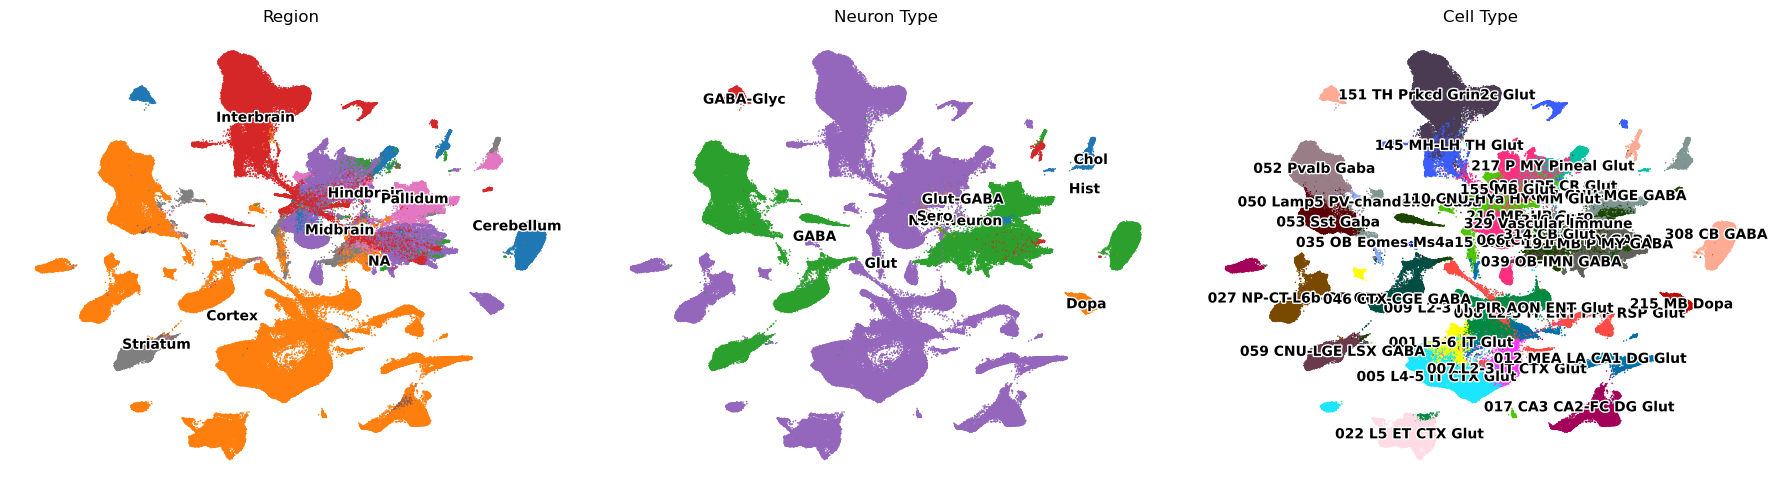

In [13]:
# UMAP plots: Region, Neuron Type, and Group Name (Cell Type)
import scanpy as sc
umap_color_cols = [
    ("region_level1", "Region"),
    ("neuron_type", "Neuron Type"),
    ("group_name", "Cell Type"),
]
available = [(col, title) for col, title in umap_color_cols if col in adata_umap.obs.columns]
n_plots = len(available)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 1:
    axes = [axes]
    
for ax, (col, title) in zip(axes, available):
    sc.pl.umap(
        adata_umap,
        color=col,
        ax=ax,
        show=False,
        title=title,
        legend_loc="on data",
        legend_fontsize=10,
        legend_fontoutline=2,
        frameon=False,
        size=5,
    )
plt.tight_layout()
plt.show()

## E-distance calculation

Next, we will identify and prioritize genes and cell types for follow-up by constructing and ranking a global perturbation-response map using E-distance matrices (compute 1-sided accelerated E-distance **per target gene and cell type (group_name)** in PCA space)

* If the file to store PCA does not exist yet, we first make sure the PCA embedding is a concrete array and free unnecessary GPU memory.
* For each cell type, build an AnnData object that contains only its cells and their PCA coordinates.
* For each cell type with control (e.g., Non_target) cells, we compute pairwise E-distance between every perturbation group and the control.
* We record the one-sided E-distance (target vs. control) for each gene, building a table of gene–cell-type effect sizes.
* Combine all results into a single DataFrame and save to disk


In [14]:
from tqdm import tqdm
onesided_path = f"{OUT_DIR}/edistance_onesided_by_celltype.csv"

In [15]:
%%time
if not os.path.exists(onesided_path):
    # Materialise PCA once
    Xp = adata.obsm["X_pca"]
    if hasattr(Xp, "compute"):
        Xp = Xp.compute()
    if hasattr(Xp, "get"):
        Xp = Xp.get()
    adata.obsm["X_pca"] = np.asarray(Xp)

    # ── Free GPU memory: X/layers are no longer needed ──
    # Move adata off GPU – only obs metadata + X_pca (numpy) are needed
    rsc.get.anndata_to_CPU(adata)
    if "counts" in adata.layers:
        del adata.layers["counts"]
    del adata.X
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()

    celltypes = adata.obs[CELLTYPE].cat.categories if hasattr(adata.obs[CELLTYPE], "cat") else adata.obs[CELLTYPE].unique()
    celltypes = sorted(celltypes)

    all_rows = []
    for i, ct in tqdm(enumerate(celltypes), total=len(celltypes), desc=f"Processing {len(celltypes)} cell types"):
        mask = adata.obs[CELLTYPE] == ct
        # Build AnnData with only PCA + obs (no X/layers)
        obs_ct = adata.obs[mask].copy()
        obs_ct[GROUPBY] = obs_ct[GROUPBY].cat.remove_unused_categories()
        adata_ct = ad.AnnData(
            obs=obs_ct,
            obsm={"X_pca": adata.obsm["X_pca"][mask.values]},
        )
        n_targets = adata_ct.obs[GROUPBY].nunique()

        # Skip cell types with no control cells
        if CONTROL not in adata_ct.obs[GROUPBY].values:
            print(f"  [{i+1}/{len(celltypes)}] {ct}: no {CONTROL} cells – skipped")
            del adata_ct
            continue

        distance = EDistance(metric="edistance", obsm_key="X_pca")
        edist_pw = distance.pairwise(adata_ct, groupby=GROUPBY, multi_gpu=[0,1])

        # Extract the one-sided distance: compare each target → control
        if CONTROL in edist_pw.columns:
            for target_label in edist_pw.index:
                target = str(target_label)
                if target == CONTROL:
                    continue
                all_rows.append({
                    "target": target,
                    "celltype": ct,
                    "edistance": float(edist_pw.loc[target_label, CONTROL]),
                })

        # Free memory
        del edist_pw, distance, adata_ct
        gc.collect()
        cp.get_default_memory_pool().free_all_blocks()
    edist_ct = pd.DataFrame(all_rows)
    edist_ct.to_csv(onesided_path, index=False)
    print(f"\nSaved {len(edist_ct)} rows to {onesided_path}")
else:
    edist_ct = pd.read_csv(onesided_path)

edist_ct.head(10)


Processing 31 cell types: 100%|██████████| 31/31 [01:13<00:00,  2.38s/it]


Saved 51270 rows to /notebooks/notebooks/singlet_gex.zarr/edistance_onesided_by_celltype.csv
CPU times: user 1min 23s, sys: 1.02 s, total: 1min 24s
Wall time: 1min 15s


,target,celltype,edistance
0,Abat,001 L5-6 IT Glut,-0.057895
1,Abca1,001 L5-6 IT Glut,-0.041489
2,Abca7,001 L5-6 IT Glut,0.003942
3,Abcb7,001 L5-6 IT Glut,-0.059195
4,Abcc9,001 L5-6 IT Glut,-0.038461
5,Abcd3,001 L5-6 IT Glut,-0.073276
6,Abhd2,001 L5-6 IT Glut,0.016457
7,Abhd12,001 L5-6 IT Glut,0.013110
8,Acat1,001 L5-6 IT Glut,0.060079
9,Acbd5,001 L5-6 IT Glut,-0.103241


# E-distance exploration

Of the 1,947 genes included in the brain CRISPR atlas, nearly all correspond to mouse homologs of human disease-associated genes, including neurodevelopmental disorders, psychiatric and neurodegenerative conditions. We can explore whether perturbation of these disease gene sets produces transcriptional effects enriched in specific neuronal populations. We will use essential gene perturbations from Blomen et. al, Science 2015 as an example. Essential genes are critical for cell fitness and we would expect more perturbation effects (e.g. higher e-distance) when they are disrupted than non-essential genes. 

In this example, we focus on 2 cell types ranked by highest cell coverage per perturbation, 151 TH Prkcd Grin2c Glut, neurons mapping to the thalamus, as well as 155 MB Glut, a set of glutamatergic neurons located in the midbrain. 

* Subset the data by cell types of interest.
* Plot the data between perturbed nonessential and essential genes.
* We expect and demonstrate that target genes that are essential will exhibit higher e-distance than non-essential genes.
* We calculate a one-sided Mann-Whitney U/Wilcoxon Rank Sum test to determine if the increase in e-distance from essential genes is significantly higher than non-essential genes.


In [16]:
from scipy.stats import mannwhitneyu
# Load the gene database
gene_db_blomen = pd.read_csv("../data/genes_of_interest_blomen.csv")

In [17]:
# 2. Filter and Join for top cell types of interest
CELL_TYPES_OF_INTEREST = [
    "151 TH Prkcd Grin2c Glut",
    "155 MB Glut",
]

edist_blomen = edist_ct[
    (edist_ct['celltype'].isin(CELL_TYPES_OF_INTEREST)) &
    (edist_ct['edistance'] > 0.1)
].copy()

# Inner join: target (from edist) and gene (from gene_db_blomen)
edist_blomen = edist_blomen.merge(gene_db_blomen, left_on='target', right_on='gene')

display(edist_blomen.groupby('celltype').size().rename("n_genes"))

celltype
151 TH Prkcd Grin2c Glut    60
155 MB Glut                 46
Name: n_genes, dtype: int64

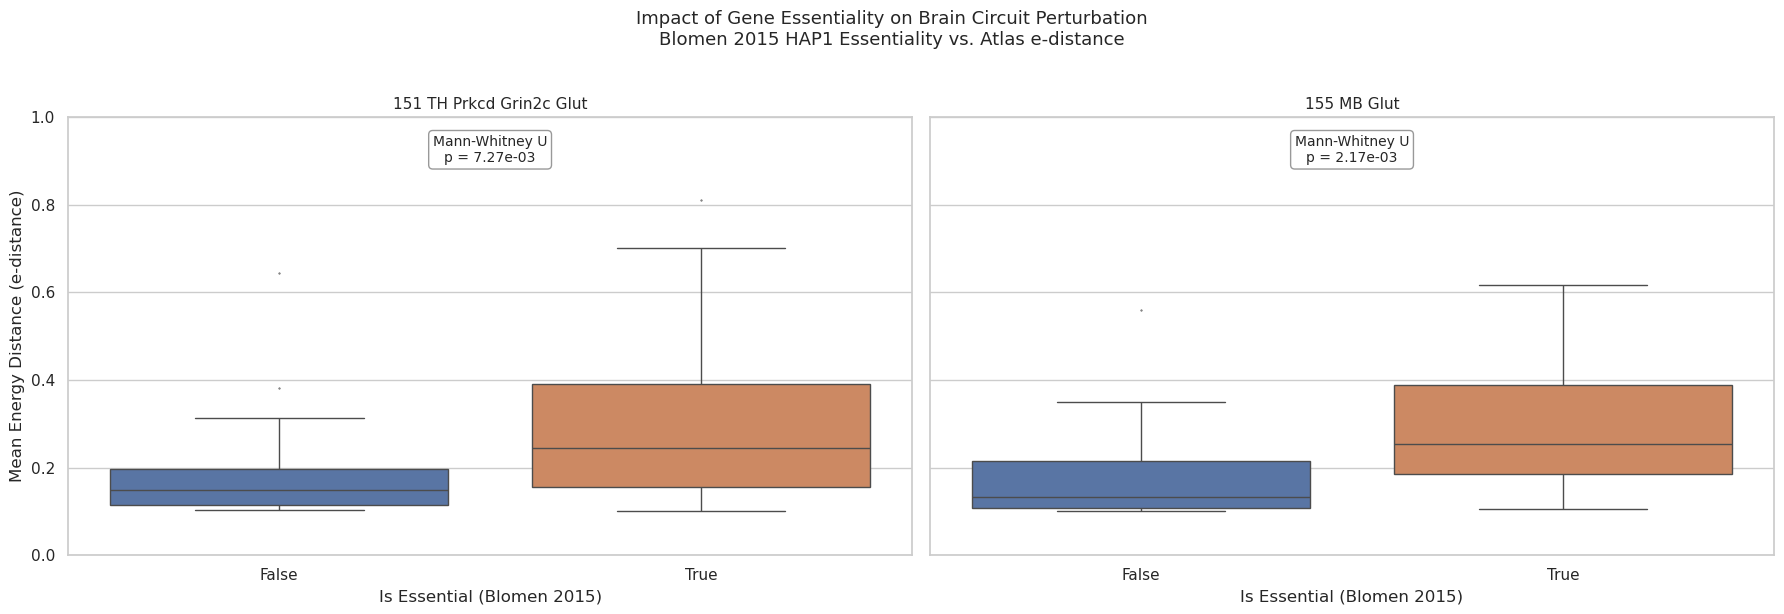

In [18]:
# Plotting with Seaborn — one panel per cell type, Mann-Whitney U on each plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, len(CELL_TYPES_OF_INTEREST), figsize=(18, 6), sharey=True)

for ax, ct in zip(axes, CELL_TYPES_OF_INTEREST):
    subset = edist_blomen[edist_blomen['celltype'] == ct]

    sns.boxplot(
        data=subset,
        x='blomen_essential',
        y='edistance',
        fliersize=0.5,
        hue='blomen_essential',
        legend=False,
        ax=ax,
    )

    ax.set_ylim(0, 1)
    ax.set_title(ct, fontsize=11)
    ax.set_xlabel("Is Essential (Blomen 2015)")
    ax.set_ylabel("Mean Energy Distance (e-distance)" if ax is axes[0] else "")

    # Mann-Whitney U
    ess = subset[subset['blomen_essential'] == True]['edistance']
    non = subset[subset['blomen_essential'] == False]['edistance']
    if len(ess) > 0 and len(non) > 0:
        stat, p = mannwhitneyu(ess, non, alternative='greater')
        p_str = f"p = {p:.2e}" if p >= 1e-4 else f"p < 1e-4"
        ax.text(
            0.5, 0.96, f"Mann-Whitney U\n{p_str}",
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8),
        )
    else:
        ax.text(0.5, 0.96, "insufficient data", transform=ax.transAxes,
                ha='center', va='top', fontsize=9, color='grey')

fig.suptitle(
    "Impact of Gene Essentiality on Brain Circuit Perturbation\n"
    "Blomen 2015 HAP1 Essentiality vs. Atlas e-distance",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

In [19]:
#Summary table of Mann-Whitney U results for all cell types
rows = []
for ct in CELL_TYPES_OF_INTEREST:
    subset = edist_blomen[edist_blomen['celltype'] == ct]
    ess = subset[subset['blomen_essential'] == True]['edistance']
    non = subset[subset['blomen_essential'] == False]['edistance']
    if len(ess) > 0 and len(non) > 0:
        stat, p = mannwhitneyu(ess, non, alternative='greater')
        rows.append({"cell_type": ct, "n_essential": len(ess), "n_non_essential": len(non),
                     "U_statistic": stat, "p_value": p})
    else:
        rows.append({"cell_type": ct, "n_essential": len(ess), "n_non_essential": len(non),
                     "U_statistic": None, "p_value": None})

display(pd.DataFrame(rows))

,cell_type,n_essential,n_non_essential,U_statistic,p_value
0,151 TH Prkcd Grin2c Glut,42,18,530.0,0.007265
1,155 MB Glut,32,14,344.0,0.002167
